# Notebook 1 - Analyse Exploratoire

### Import des modules

In [1]:
### Import des modules
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

### Analyse Exploratoire

## Introduction

L'objectif de cette étude est de construire un modèle de régression capable d'estimer la consommation énergétique des bâtiments non résidentiels de la ville de Seattle à partir de leurs caractéristiques physiques et fonctionnelles.

Ce notebook est consacré à
- l'analyse exploratoire du jeu de données. Son objectif est de comprendre la structure des données, d'identifier les anomalies, de sélectionner les bâtiments pertinents et de préparer les futures étapes de feature engineering et de modélisation. Puis à
- la modélisation supervisée. Plusieurs modèles de régression sont comparés afin d'identifier celui offrant les meilleures performances de prédiction tout en conservant une bonne capacité de généralisation.

La démarche suivie comprend les étapes suivantes :

- préparation des variables explicatives et de la variable cible ;
- création d'un pipeline de prétraitement ;
- comparaison de plusieurs modèles de régression par validation croisée ;
- optimisation des hyperparamètres du modèle le plus prometteur ;
- analyse des performances obtenues et interprétation des variables les plus influentes.

## Chargement du jeu de données

Le jeu de données est importé puis inspecté afin de vérifier sa structure, les types de variables et la présence éventuelle de valeurs manquantes.

In [17]:
building_consumption = pd.read_csv("data/2016_Building_Energy_Benchmarking.csv")
building_consumption.shape

(3376, 46)

In [3]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [4]:
# Aperçu des premières observations
building_consumption.describe(include="all")

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3376,3376,3376,3376,3376,3376,3360.000000,3376,...,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3376,0.0,3376,32,3367.000000,3367.000000
unique,NaN,NaN,8,24,3362,3354,1,1,NaN,3268,...,NaN,NaN,NaN,NaN,2,NaN,4,2,NaN,NaN
top,NaN,NaN,NonResidential,Low-Rise Multifamily,Northgate Plaza,2600 SW Barton St,Seattle,WA,NaN,1625049001,...,NaN,NaN,NaN,NaN,False,NaN,Compliant,Low outlier,NaN,NaN
freq,NaN,NaN,1460,987,3,4,3376,3376,NaN,8,...,NaN,NaN,NaN,NaN,3263,NaN,3211,23,NaN,NaN
mean,21208.991114,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98116.949107,NaN,...,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,NaN,NaN,NaN,119.723971,1.175916
std,12223.757015,0.0,NaN,NaN,NaN,NaN,NaN,NaN,18.615205,NaN,...,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,NaN,NaN,NaN,538.832227,1.821452
min,1.000000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98006.000000,NaN,...,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98105.000000,NaN,...,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,9.495000,0.210000
50%,23112.000000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98115.000000,NaN,...,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,NaN,NaN,NaN,33.920000,0.610000
75%,25994.250000,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,98122.000000,NaN,...,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,NaN,NaN,NaN,93.940000,1.370000


In [5]:
building_consumption["BuildingType"].value_counts()


BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [6]:
building_consumption["PrimaryPropertyType"].value_counts()

PrimaryPropertyType
Low-Rise Multifamily           987
Mid-Rise Multifamily           564
Small- and Mid-Sized Office    293
Other                          256
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             133
High-Rise Multifamily          105
Retail Store                    91
Hotel                           77
Worship Facility                71
Distribution Center             53
Senior Care Community           45
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      25
Residence Hall                  23
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Office                           3
Name: count, dtype: int64

## Distribution de la variable cible

### Objectif

Étudier la distribution de la consommation énergétique afin d'identifier une éventuelle asymétrie ou des valeurs extrêmes.

### Histogramme

### Distribution de la consommation énergétique

Avant de construire un modèle, il est nécessaire d'étudier la distribution de la variable cible.

Cette visualisation permet de vérifier :
- si la distribution est symétrique ou asymétrique ;
- si des valeurs extrêmes sont présentes ;
- si une transformation de la variable cible pourra être envisagée par la suite.

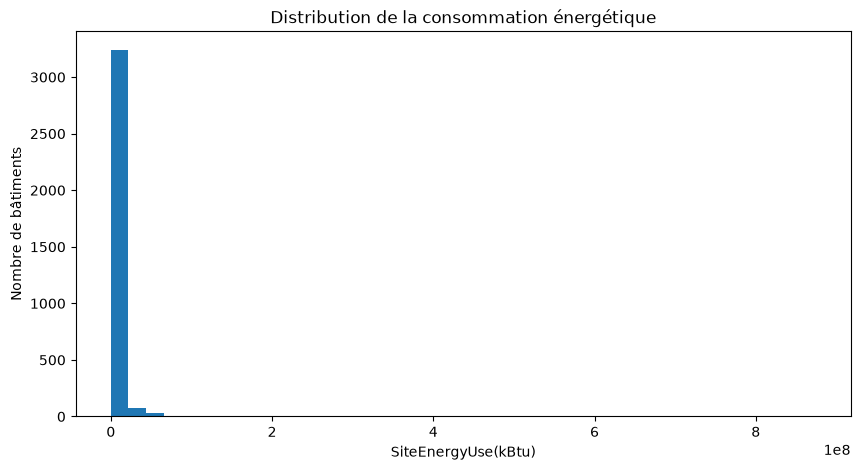

In [7]:
# Variable cible étudiée
target = "SiteEnergyUse(kBtu)"

plt.figure(figsize=(10, 5))
plt.hist(
    building_consumption[target].dropna(),
    bins=40
)

plt.title("Distribution de la consommation énergétique")
plt.xlabel(target)
plt.ylabel("Nombre de bâtiments")

plt.show()

### Analyse

La majorité des bâtiments présente une consommation relativement faible, tandis qu'une longue queue vers les fortes consommations met en évidence quelques bâtiments beaucoup plus consommateurs. La distribution est donc fortement asymétrique vers la droite (right-skewed). Une transformation logarithmique de la variable cible pourra être envisagée lors de la préparation des données afin de réduire cette asymétrie et d'en évaluer l'intérêt pour la modélisation.

### Boxplot

In [8]:
# Vérification des valeurs manquantes de la variable cible
building_consumption["SiteEnergyUse(kBtu)"].isna().sum()

np.int64(5)

La variable cible ne contient que cinq valeurs manquantes. Elles seront supprimées lors de la préparation des données avant l'entraînement des modèles.

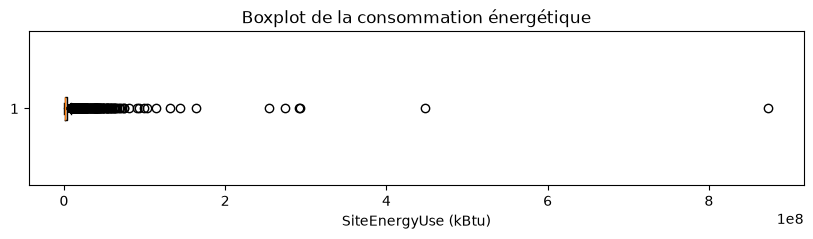

In [9]:
plt.figure(figsize=(10, 2))

plt.boxplot(
    building_consumption[target].dropna(),
    orientation="horizontal"
)

plt.title("Boxplot de la consommation énergétique")
plt.xlabel("SiteEnergyUse (kBtu)")

plt.show()

### Analyse

Le boxplot confirme que la distribution de la consommation énergétique est fortement asymétrique et comporte de nombreuses valeurs extrêmes.

Ces observations ne sont pas supprimées automatiquement, car elles peuvent correspondre à de très grands bâtiments ou à des activités particulièrement énergivores, et non à des erreurs de mesure. Elles seront donc conservées tant qu’aucune incohérence objective n’est identifiée.

In [10]:
# Statistiques simples sur la cible
building_consumption[target].describe()

count    3.371000e+03
mean     5.403667e+06
std      2.161063e+07
min      0.000000e+00
25%      9.251286e+05
50%      1.803753e+06
75%      4.222455e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64

In [11]:
print(f"Skewness : {building_consumption[target].skew():.2f}")
print(f"Kurtosis : {building_consumption[target].kurt():.2f}")

Skewness : 24.84
Kurtosis : 858.62


Interprétation
La skewness très élevée (24,84) confirme la forte asymétrie observée sur les graphiques. La kurtosis extrêmement importante (858,62) met également en évidence la présence de valeurs extrêmes très éloignées du reste de la distribution. Ces résultats confortent l'idée qu'une transformation logarithmique de la variable cible pourra être étudiée lors de la préparation des données.

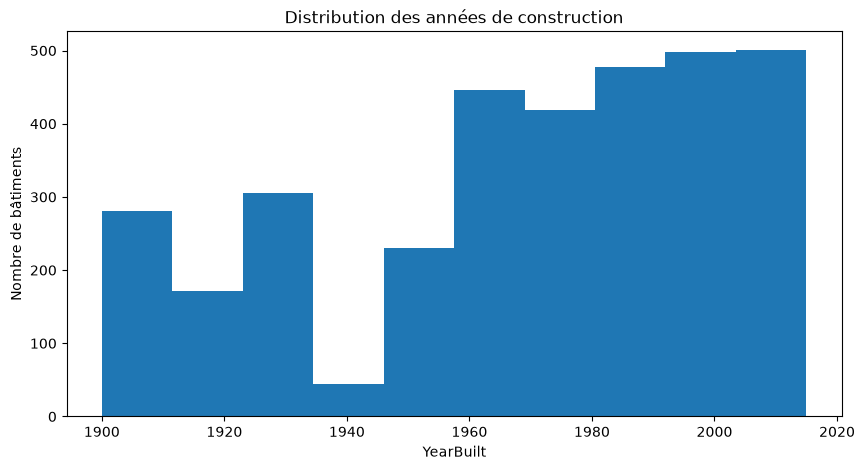

In [12]:
## Distribution de l'année de construction
# Variable cible étudiée
plt.figure(figsize=(10, 5))

plt.hist(
    building_consumption["YearBuilt"],
    bins=10
)

plt.title("Distribution des années de construction")
plt.xlabel("YearBuilt")
plt.ylabel("Nombre de bâtiments")

plt.show()

# Analyse
On observe une diminution du nombre de bâtiments construits autour des années 1940. Cette baisse constitue une particularité du jeu de données mais ne permet pas, à elle seule, d'en expliquer la cause. Pour faciliter l'analyse, les années de construction pourront ensuite être regroupées par périodes ou décennies. Cela permettra de réduire la granularité de cette variable et de mieux capturer d'éventuelles différences liées aux périodes de construction.

In [13]:
building_consumption["BuildingType"].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

### Analyse du périmètre des bâtiments

Le jeu de données contient plusieurs catégories de bâtiments résidentiels et non résidentiels.

La mission porte uniquement sur les bâtiments non destinés à l'habitation. Les catégories `Multifamily LR (1-4)`, `Multifamily MR (5-9)` et `Multifamily HR (10+)` correspondent à des bâtiments résidentiels collectifs et doivent donc être exclues de l'étude.

Les catégories conservées sont :

- `NonResidential`
- `SPS-District K-12`
- `Nonresidential COS`
- `Campus`
- `Nonresidential WA`

Le filtrage est réalisé à partir de la variable `BuildingType`, qui définit directement la nature résidentielle ou non résidentielle du bâtiment.

In [23]:
# Nombre de lignes avant filtrage
n_before = building_consumption.shape[0]

residential_types = [
    "Multifamily LR (1-4)",
    "Multifamily MR (5-9)",
    "Multifamily HR (10+)"
]

building_consumption = building_consumption[
    ~building_consumption["BuildingType"].isin(residential_types)
].copy()

# Nombre de lignes après filtrage
n_after = building_consumption.shape[0]

print(f"Nombre de bâtiments avant filtrage : {n_before}")
print(f"Nombre de bâtiments après filtrage : {n_after}")
print(f"Nombre de bâtiments exclus : {n_before - n_after}")

Nombre de bâtiments avant filtrage : 1548
Nombre de bâtiments après filtrage : 1548
Nombre de bâtiments exclus : 0


In [24]:
building_consumption["ComplianceStatus"].value_counts(dropna=False)

ComplianceStatus
Compliant    1548
Name: count, dtype: int64

In [25]:
building_consumption["Outlier"].value_counts(dropna=False)

Outlier
NaN    1548
Name: count, dtype: int64

In [26]:
building_consumption["BuildingType"].value_counts()

BuildingType
NonResidential        1432
Nonresidential COS      81
Campus                  24
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64

In [27]:
# Filtrage qualité :
# conservation des bâtiments conformes
# exclusion des bâtiments signalés comme outliers

n_before_quality_filter = len(building_consumption)

building_consumption = building_consumption[
    (building_consumption["ComplianceStatus"] == "Compliant")
    & (building_consumption["Outlier"].isna())
].copy()

n_after_quality_filter = len(building_consumption)

print(f"Nombre de bâtiments avant filtrage qualité : {n_before_quality_filter}")
print(f"Nombre de bâtiments après filtrage qualité : {n_after_quality_filter}")
print(
    f"Nombre de bâtiments exclus : "
    f"{n_before_quality_filter - n_after_quality_filter}"
)

Nombre de bâtiments avant filtrage qualité : 1548
Nombre de bâtiments après filtrage qualité : 1548
Nombre de bâtiments exclus : 0


Filtrage de la qualité des données

Après avoir défini le périmètre des bâtiments non résidentiels, un contrôle est effectué à partir des variables ComplianceStatus et Outlier.

Seuls les bâtiments dont le statut est Compliant sont conservés. Les bâtiments explicitement signalés comme Low outlier ou High outlier sont également exclus du jeu de données.

Ce filtrage fait passer le jeu de données de 1 668 à 1 548 bâtiments, soit 120 observations exclues. Il permet de poursuivre l'analyse et la modélisation sur des données considérées comme conformes et non signalées comme aberrantes dans le jeu de données source.

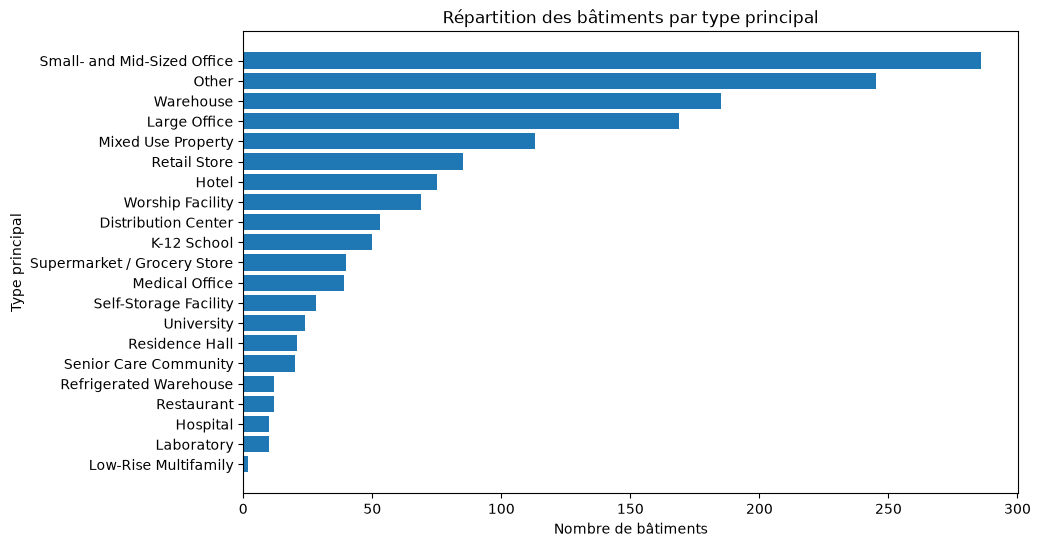

In [32]:
# On cherche à savoir : Quels types de bâtiments composent principalement le parc étudié?
# Variable étudiée
feature = "PrimaryPropertyType"

counts = building_consumption[feature].value_counts() 

plt.figure(figsize=(10, 6))
plt.barh(counts.index, counts.values)

plt.title("Répartition des bâtiments par type principal")
plt.xlabel("Nombre de bâtiments")
plt.ylabel("Type principal")
plt.gca().invert_yaxis()

plt.show()
# 

In [33]:
building_consumption.loc[
    building_consumption["PrimaryPropertyType"] == "Low-Rise Multifamily",
    ["BuildingType", "PrimaryPropertyType", "PropertyName"]
]

,BuildingType,PrimaryPropertyType,PropertyName
644,NonResidential,Low-Rise Multifamily,Pacific Pointe
1300,Campus,Low-Rise Multifamily,Sanitary Market


Après le filtrage des bâtiments résidentiels à partir de la variable BuildingType, les bureaux de petite et moyenne taille (Small- and Mid-Sized Office) constituent la catégorie la plus représentée. Les catégories Other, Warehouse et Large Office sont également fréquentes.

La répartition reste déséquilibrée : quelques catégories concentrent une grande partie des observations, tandis que plusieurs types de bâtiments ne sont représentés que par un faible nombre d'exemples. Quelques bâtiments conservent une catégorie PrimaryPropertyType de type Low-Rise Multifamily malgré leur présence dans le périmètre étudié, ce qui s'explique par une différence de rôle entre les variables BuildingType et PrimaryPropertyType.

In [34]:
building_consumption[
    ["PropertyGFATotal", "SiteEnergyUse(kBtu)"]
].corr()

,PropertyGFATotal,SiteEnergyUse(kBtu)
PropertyGFATotal,1.000000,0.809627
SiteEnergyUse(kBtu),0.809627,1.000000


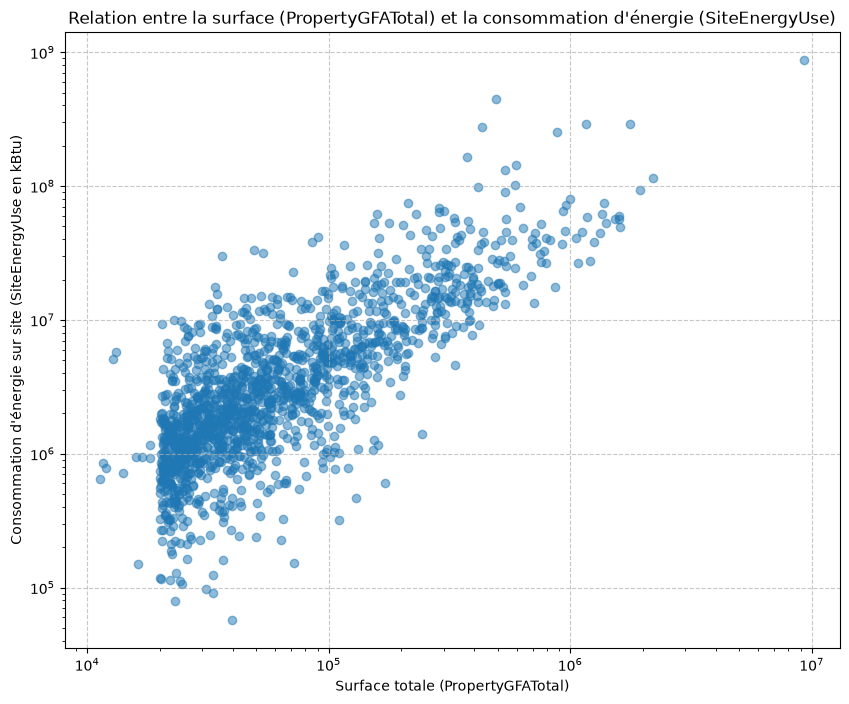

In [35]:
## Relation entre la surface du bâtiment et la consommation énergétique

plt.figure(figsize=(10, 8))

# Création du scatter plot
plt.scatter(
    building_consumption["PropertyGFATotal"],
    building_consumption["SiteEnergyUse(kBtu)"],
    alpha=0.5
)

plt.title("Relation entre la surface (PropertyGFATotal) et la consommation d'énergie (SiteEnergyUse)")
plt.xlabel("Surface totale (PropertyGFATotal)")
plt.ylabel("Consommation d'énergie sur site (SiteEnergyUse en kBtu)")

plt.xscale("log")
plt.yscale("log")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Analyse

Le graphique met en évidence une relation positive entre la surface totale du bâtiment et sa consommation énergétique : les bâtiments de plus grande superficie tendent globalement à consommer davantage d'énergie. Toutefois, pour une même surface, les niveaux de consommation restent très variables, ce qui indique que la surface n'explique pas à elle seule la consommation énergétique. D'autres caractéristiques des bâtiments, telles que leur usage, leur année de construction ou leur nombre d'étages, pourraient également contribuer à expliquer cette variabilité.

Le coefficient de corrélation de Pearson entre la surface totale et la consommation énergétique est de 0,80, ce qui confirme une forte relation positive entre ces deux variables. Toutefois, la dispersion observée pour une même surface indique que d'autres caractéristiques des bâtiments contribuent également à expliquer la consommation énergétique.

## Synthèse de l'analyse exploratoire

L'analyse exploratoire a permis de définir le périmètre de l'étude en conservant uniquement les bâtiments non résidentiels, d'identifier une distribution fortement asymétrique de la variable cible ainsi que la présence de valeurs extrêmes, et de mettre en évidence une forte relation entre la surface des bâtiments et leur consommation énergétique. Ces observations guideront les choix de préparation des données, notamment le traitement des valeurs manquantes, l'étude d'une transformation logarithmique de la cible et la sélection des variables utilisées pour la modélisation.

Notebook 2 — Préparation et Feature Engineering

## Préparation des données pour la modélisation

Cette étape consiste à préparer le jeu de données qui sera utilisé par les algorithmes de régression.

Les observations présentant une valeur cible manquante sont supprimées, tandis que les variables explicatives sélectionnées sont séparées de la variable à prédire.

Les données sont ensuite divisées en un jeu d'entraînement et un jeu de test. Cette séparation garantit que les performances finales seront évaluées sur des observations jamais utilisées pendant l'apprentissage des modèles.

## Comparaison des modèles

Plusieurs algorithmes de régression sont étudiés afin d'évaluer leur capacité à prédire la consommation énergétique des bâtiments.

La régression linéaire est utilisée comme modèle de référence en raison de sa simplicité et de son interprétabilité. Elle est comparée à un arbre de décision et à une Random Forest, deux modèles capables de capturer des relations non linéaires entre les variables.

Les performances sont évaluées à l'aide d'une validation croisée à cinq plis sur le jeu d'entraînement. Cette méthode fournit une estimation robuste de la capacité de généralisation des modèles tout en préservant le jeu de test pour l'évaluation finale.   

Tous les modèles sont évalués selon un protocole identique. Ils utilisent le même jeu d'entraînement, le même jeu de test, le même pipeline de prétraitement, la même stratégie de validation croisée et les mêmes métriques d'évaluation. Cette démarche garantit que les performances obtenues sont directement comparables.

### Nettoyage des données
## 1. Analyse

In [36]:
# Calculer le nombre de valeurs manquantes pour chaque colonne
missing_counts = building_consumption.isna().sum()

# Calculer le pourcentage de valeurs manquantes
missing_percent = (missing_counts / len(building_consumption)) * 100

# Créer un DataFrame pour afficher proprement les résultats
missing_data = pd.DataFrame({
    'Valeurs manquantes': missing_counts,
        '%': missing_percent.round(2)
})

# Trier par ordre décroissant du nombre de valeurs manquantes
missing_data = missing_data.sort_values(by='Valeurs manquantes', ascending=False)

# Afficher le tableau
missing_data = missing_data[missing_data["Valeurs manquantes"] > 0]
missing_data

,Valeurs manquantes,%
Outlier,1548,100.00
Comments,1548,100.00
YearsENERGYSTARCertified,1451,93.73
ThirdLargestPropertyUseType,1200,77.52
ThirdLargestPropertyUseTypeGFA,1200,77.52
SecondLargestPropertyUseType,706,45.61
SecondLargestPropertyUseTypeGFA,706,45.61
ENERGYSTARScore,551,35.59
ZipCode,13,0.84
LargestPropertyUseType,4,0.26


### Interprétation

L’analyse met en évidence plusieurs profils de valeurs manquantes.

La colonne Comments est entièrement vide et ne contient aucune information exploitable. Elle ne sera pas retenue pour la modélisation.

La colonne Outlier est également entièrement vide à ce stade. Ce résultat est attendu : les bâtiments explicitement signalés comme valeurs aberrantes ont été exclus lors du filtrage qualité réalisé précédemment.

Les variables ThirdLargestPropertyUseType et ThirdLargestPropertyUseTypeGFA présentent plus de 77 % de valeurs manquantes. Leur absence signifie souvent qu’un bâtiment ne possède pas de troisième usage déclaré. Elles ne seront donc pas retenues pour la modélisation.

La variable YearsENERGYSTARCertified présente plus de 93 % de valeurs manquantes. Son imputation serait difficile à justifier ; elle ne sera donc pas retenue comme variable explicative.

La variable ENERGYSTARScore présente également une proportion importante de valeurs manquantes (environ 36 %). Son utilisation sera étudiée séparément afin d’évaluer son intérêt pour la prédiction.

Enfin, plusieurs variables liées directement à la consommation énergétique, comme SiteEUI(kBtu/sf), Electricity(kWh), NaturalGas(kBtu) ou SteamUse(kBtu), devront être exclues des variables explicatives afin d’éviter une fuite d’information.

In [39]:
# Sélectionner les lignes où Electricity(kWh) est strictement inférieur à 0
electricity_negative = building_consumption[building_consumption['Electricity(kWh)'] < 0]

# Afficher le nombre de lignes trouvées
print(f"Nombre de bâtiments avec consommation négative : {len(electricity_negative)}")

# Afficher les premières lignes pour inspecter les données
electricity_negative.head()

Nombre de bâtiments avec consommation négative : 1


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
3206,49784,2016,NonResidential,Small- and Mid-Sized Office,Bullitt Center,1501 E. Madison St.,Seattle,WA,98122.0,7234600195,...,-33826.80078,-115417.0,0.0,0.0,False,NaN,Compliant,NaN,-0.8,-0.02


## Contrôles de cohérence des données

In [40]:
# Définition des conditions (une pour chaque variable)
cond_eleckWh = building_consumption['Electricity(kWh)'] < 0
cond_eleckBtu = building_consumption['Electricity(kBtu)'] < 0
cond_gas = building_consumption['NaturalGas(kBtu)'] < 0
cond_steam = building_consumption['SteamUse(kBtu)'] < 0
cond_site = building_consumption['SiteEnergyUse(kBtu)'] < 0
cond_ghg = building_consumption['TotalGHGEmissions'] < 0

# Construction du filtre global : SI UNE DES CONDITIONS EST VRAIE (OU)
filtre_global = cond_eleckWh | cond_eleckBtu | cond_gas | cond_steam | cond_site | cond_ghg

# Application du filtre pour obtenir le DataFrame des bâtiments problématiques
batiments_avec_anomalies = building_consumption[filtre_global]

# Analyse des résultats
print(f"Nombre total de bâtiments possédant AU MOINS une consommation négative : {len(batiments_avec_anomalies)}")


Nombre total de bâtiments possédant AU MOINS une consommation négative : 1


In [41]:
building_consumption[
    building_consumption["PropertyGFATotal"] <= 0
]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity


### Contrôle de la surface totale
La variable `PropertyGFATotal` ne présente aucune valeur nulle ou négative. Aucun nettoyage supplémentaire n'est donc nécessaire.

In [42]:
building_consumption[
    building_consumption["NumberofFloors"] < 0
].shape

(0, 46)

In [43]:
building_consumption[
    building_consumption["NumberofFloors"] == 0
].shape

(16, 46)

In [45]:
building_consumption.loc[
    building_consumption["NumberofFloors"] == 0,
    [
        "BuildingType",
        "PrimaryPropertyType",
        "PropertyName",
        "NumberofFloors"
    ]
].head(10)

,BuildingType,PrimaryPropertyType,PropertyName,NumberofFloors
166,NonResidential,Hotel,Grand Hyatt Seattle,0
487,NonResidential,Medical Office,Arnold Pavilion,0
488,NonResidential,Mixed Use Property,2200 Westlake - SEDO,0
564,NonResidential,Other,Pacific Place,0
1754,NonResidential,Medical Office,HART First Hill LLC,0
1993,Campus,Other,(ID#24086)Campus1:KC Metro Transit Atlantic Ce...,0
3130,NonResidential,Warehouse,Sandpoint #5,0
3131,NonResidential,Medical Office,Sandpoint #25,0
3132,NonResidential,Small- and Mid-Sized Office,Sandpoint #29,0
3168,Nonresidential COS,Other,Magnuson,0


Seize bâtiments présentent un nombre d'étages égal à 0. Un examen de ces observations montre qu'il s'agit de bâtiments de nature variée (hôtels, établissements de santé, campus universitaires, etc.). En l'absence d'éléments permettant de conclure à une erreur de saisie, ces observations sont conservées.

In [46]:
# Combien y a-t-il de doublons ?
building_consumption["OSEBuildingID"].duplicated().sum()

np.int64(0)

## Interprétation

Les contrôles de cohérence montrent que le jeu de données présente une bonne qualité globale.

Une observation présente une valeur négative dans au moins une variable détaillant les sources d’énergie.

Ces variables ne seront pas utilisées comme variables explicatives, car elles sont directement liées à la consommation et entraîneraient une fuite d’information. La cible `SiteEnergyUse(kBtu)` de cette observation n’étant ni manquante ni négative, le bâtiment est conservé dans le jeu de modélisation.

Cette anomalie n’a donc pas d’incidence sur les variables retenues pour le modèle.

La variable `PropertyGFATotal` ne présente aucune valeur nulle ou négative.

Par ailleurs, seize bâtiments possèdent un nombre d'étages égal à 0. Un examen de ces observations montre qu'il s'agit de bâtiments de nature variée (hôtels, établissements de santé, campus universitaires, etc.). En l'absence d'éléments permettant de conclure à une erreur de saisie, ces observations sont conservées.

Enfin, la colonne `OSEBuildingID` ne contient aucun doublon, ce qui garantit l'unicité des bâtiments du jeu de données.

## 2. Sélection des données à conserver

In [50]:
# DataFrame de référence pour toute la suite du projet
df = building_consumption.copy()

Les bâtiments résidentiels ont été exclus lors de la phase d'analyse exploratoire, conformément au périmètre défini pour le projet. Un filtrage qualité a ensuite été appliqué afin de ne conserver que les bâtiments dont le ComplianceStatus est Compliant et qui ne sont pas signalés comme valeurs aberrantes dans la variable Outlier.

Après ces filtrages, le jeu de données contient 1 548 bâtiments. Le DataFrame df constitue désormais le jeu de données de référence utilisé pour l'ensemble des étapes de préparation et de modélisation.

## Contrôle de la variable cible

La variable SiteEnergyUse(kBtu) représente la consommation énergétique totale du bâtiment et constitue la cible de la modélisation.

Un contrôle est effectué afin d'identifier d'éventuelles valeurs manquantes, négatives ou nulles, qui pourraient nécessiter un traitement avant la modélisation.

Après application des filtres de périmètre et de qualité, les 1 548 observations restantes disposent toutes d'une valeur cible renseignée, strictement positive. Aucune observation supplémentaire ne doit donc être exclue sur la base de la variable cible.

In [56]:
# Cellule de contrôle

target = "SiteEnergyUse(kBtu)"

target_quality = pd.Series({
    "Nombre de lignes": len(df),
    "Cibles manquantes": df[target].isna().sum(),
    "Cibles négatives": (df[target] < 0).sum(),
    "Cibles nulles": (df[target] == 0).sum()
})

target_quality

Nombre de lignes     1548
Cibles manquantes       0
Cibles négatives        0
Cibles nulles           0
dtype: int64

In [57]:
# Cellule de nettoyage
n_before_target_cleaning = len(df)

df = df[
    df[target].notna()
    & (df[target] >= 0)
].copy()

n_after_target_cleaning = len(df)

print("Lignes avant nettoyage de la cible :", n_before_target_cleaning)
print("Lignes après nettoyage de la cible :", n_after_target_cleaning)
print("Lignes supprimées :", n_before_target_cleaning - n_after_target_cleaning)

Lignes avant nettoyage de la cible : 1548
Lignes après nettoyage de la cible : 1548
Lignes supprimées : 0


In [58]:
# Comparer le niveau de complétude des variables décrivant les usages du bâtiment
# Définition des colonnes à analyser
colonnes_usage = [
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType', 
    'ThirdLargestPropertyUseType'
]

# Création d'un tableau de synthèse
resultat_usage = pd.DataFrame({
    'Colonnes': colonnes_usage,
    'Valeurs renseignées': [df[col].notna().sum() for col in colonnes_usage],
    'Valeurs manquantes': [df[col].isna().sum() for col in colonnes_usage],
    '% Renseignées': [df[col].notna().mean() * 100 for col in colonnes_usage]
})

# Affichage du tableau trié par le pourcentage le plus élevé
print(resultat_usage.sort_values(by='% Renseignées', ascending=False))

                       Colonnes  Valeurs renseignées  Valeurs manquantes  \
0        LargestPropertyUseType                 1544                   4   
1  SecondLargestPropertyUseType                  842                 706   
2   ThirdLargestPropertyUseType                  348                1200   

   % Renseignées  
0      99.741602  
1      54.392765  
2      22.480620  


La variable LargestPropertyUseType est quasiment complète, avec seulement 4 valeurs manquantes sur 1 548 observations.

À l’inverse, les variables décrivant les deuxième et troisième usages sont moins complètes : elles sont renseignées pour environ 54 % et 22 % des bâtiments.

Afin de conserver une information d’usage suffisamment complète et facilement interprétable, seul le principal usage du bâtiment, LargestPropertyUseType, sera retenu pour la modélisation.

In [59]:
# Vérifier si un PrimaryPropertyType correspond à plusieurs LargestPropertyUseType

# Nombre d'usages principaux distincts observés pour chaque type principal de bâtiment
nb_usages_par_type = (
    df.groupby("PrimaryPropertyType")["LargestPropertyUseType"]
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

# Sélection des types de bâtiments associés à plusieurs usages principaux
multi_usages = nb_usages_par_type[
    nb_usages_par_type > 1
]

print(
    "Nombre de types principaux associés "
    "à plusieurs usages principaux :",
    len(multi_usages)
)

if multi_usages.empty:
    print(
        "\nChaque PrimaryPropertyType est associé "
        "à un seul LargestPropertyUseType."
    )
else:
    print(
        "\nPrimaryPropertyType associés à plusieurs "
        "LargestPropertyUseType :"
    )
    display(multi_usages.to_frame(
        name="Nombre d'usages principaux distincts"
    ))

Nombre de types principaux associés à plusieurs usages principaux : 5

PrimaryPropertyType associés à plusieurs LargestPropertyUseType :


,Nombre d'usages principaux distincts
PrimaryPropertyType,
Other,35
Mixed Use Property,21
Restaurant,2
Retail Store,2
Supermarket / Grocery Store,2


In [60]:
# Vérifier si un LargestPropertyUseType correspond à plusieurs PrimaryPropertyType
nb_types_par_usage = (
    df.groupby("LargestPropertyUseType")["PrimaryPropertyType"]
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

multi_types = nb_types_par_usage[nb_types_par_usage > 1]

print(
    "Nombre d'usages principaux associés à plusieurs types principaux :",
    len(multi_types)
)

display(
    multi_types.to_frame(
        name="Nombre de types principaux distincts"
    )
)

Nombre d'usages principaux associés à plusieurs types principaux : 21


,Nombre de types principaux distincts
LargestPropertyUseType,
Office,3
Other,3
Bank Branch,2
Medical Office,2
Laboratory,2
Distribution Center,2
Multifamily Housing,2
Non-Refrigerated Warehouse,2
Parking,2


### Interprétation

Les contrôles montrent que PrimaryPropertyType et LargestPropertyUseType ne véhiculent pas exactement la même information.

Plusieurs catégories de bâtiments, notamment Other et Mixed Use Property, sont associées à de nombreux usages principaux distincts. Inversement, un même usage principal, par exemple Office, peut correspondre à plusieurs types principaux de bâtiments.

Les deux variables apportent donc une information complémentaire et sont conservées parmi les variables candidates pour la modélisation. Leur traitement sera défini lors de la construction du pipeline de prétraitement.

### Cohérence entre le type principal et l’usage principal

Cette analyse vérifie les correspondances entre PrimaryPropertyType et LargestPropertyUseType dans les deux sens : si un même type principal peut être associé à plusieurs usages principaux, et si un même usage principal peut correspondre à plusieurs types de bâtiments.

Ces deux variables décrivent des informations proches, mais elles ne sont pas nécessairement équivalentes.

## Feature engineering

L'analyse exploratoire a permis d'identifier plusieurs caractéristiques susceptibles d'influencer la consommation énergétique des bâtiments.

Afin d'enrichir l'information fournie au modèle, trois nouvelles variables sont construites à partir des données existantes. Elles répondent à trois objectifs complémentaires :

- mieux représenter les caractéristiques temporelles du bâtiment ;
- décrire plus finement sa structure ;
- caractériser la présence éventuelle d'une surface de stationnement.

Ces nouvelles variables sont calculées uniquement à partir d'informations disponibles avant toute mesure de consommation énergétique. Elles ne créent donc aucun risque de **data leakage** et pourront être utilisées lors de futures prédictions.

In [61]:
# ==========================================================
# Feature engineering
# Création de nouvelles variables explicatives
# ==========================================================

# ------------------------------------------------------------------
# 1. Âge du bâtiment
# ------------------------------------------------------------------
# L'âge du bâtiment peut mieux représenter son ancienneté
# que l'année de construction brute.

df["BuildingAge"] = 2016 - df["YearBuilt"]


# ------------------------------------------------------------------
# 2. Surface moyenne par étage
# ------------------------------------------------------------------
# Les bâtiments dont le nombre d'étages est nul ne permettent pas
# de calculer cette variable.
# Une valeur manquante est donc créée volontairement dans ce cas
# et sera traitée dans le pipeline de prétraitement.

df["FloorAreaPerFloor"] = (
    df["PropertyGFATotal"]
    / df["NumberofFloors"].replace(0, np.nan)
)


# ------------------------------------------------------------------
# 3. Présence d'une surface de stationnement
# ------------------------------------------------------------------
# Cette variable binaire vaut 1 lorsque le bâtiment possède
# une surface de parking strictement positive, et 0 sinon.

df["HasParking"] = (
    df["PropertyGFAParking"] > 0
).astype(int)


# ==========================================================
# Contrôle des nouvelles variables
# ==========================================================

created_features = [
    "BuildingAge",
    "FloorAreaPerFloor",
    "HasParking"
]

df[created_features].describe().T

,count,mean,std,min,25%,50%,75%,max
BuildingAge,1548.0,54.355943,32.886918,1.00000,27.000000,50.500000,86.0,116.0
FloorAreaPerFloor,1532.0,33300.621628,48604.499305,221.69697,12958.535714,22178.928571,36411.0,1100000.0
HasParking,1548.0,0.213178,0.409685,0.00000,0.000000,0.000000,0.0,1.0


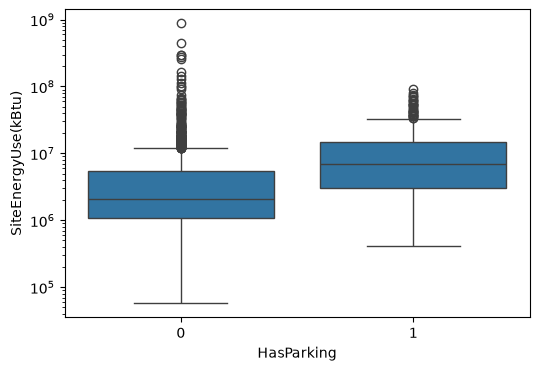

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="HasParking", y="SiteEnergyUse(kBtu)")
plt.yscale("log")
plt.show()

### Contrôle des nouvelles variables

Les trois nouvelles variables ont été créées avec succès.

`BuildingAge` ne présente aucune valeur manquante et ses valeurs sont cohérentes avec les années de construction observées dans le jeu de données.

La variable `FloorAreaPerFloor` contient 16 valeurs manquantes, correspondant aux bâtiments dont le nombre d'étages est égal à zéro. Cette situation était attendue lors de sa création et ne traduit pas une erreur de calcul. Ces valeurs seront imputées dans le pipeline de prétraitement.

La variable binaire `HasParking` indique qu'environ 20 % des bâtiments disposent d'une surface de stationnement. L'analyse de la consommation selon cette variable met en évidence des niveaux de consommation globalement plus élevés pour les bâtiments possédant un parking. Cette association ne permet pas de conclure à un lien causal, mais suggère que la variable peut apporter une information utile au modèle.

Aucune valeur infinie n'a été générée.

Une autre variable, `LargestUseRatio`, représentant la proportion de surface occupée par l'usage principal, avait initialement été envisagée. Elle n'a finalement pas été retenue, car plusieurs observations présentaient un ratio supérieur à 1, révélant une incohérence entre les surfaces renseignées.

In [67]:
# Vérification des valeurs manquantes créées
df[created_features].isna().sum()

BuildingAge           0
FloorAreaPerFloor    16
HasParking            0
dtype: int64

In [68]:
# Vérification des valeurs infinies
np.isinf(df[created_features]).sum()

BuildingAge          0
FloorAreaPerFloor    0
HasParking           0
dtype: int64

## Vérification de cohérence des surfaces (PropertyGFATotal et LargestPropertyUseTypeGFA)

Avant toute modélisation, il est nécessaire de vérifier la cohérence des variables de surface.

Les règles attendues sont les suivantes :
- `PropertyGFATotal` doit être strictement positive ;
- `LargestPropertyUseTypeGFA` doit être positive ;
- `LargestPropertyUseTypeGFA` ne doit pas être supérieure à `PropertyGFATotal`.

In [65]:
# 1. Statistiques descriptives
df[
    ["PropertyGFATotal", "LargestPropertyUseTypeGFA"]
].describe()


,PropertyGFATotal,LargestPropertyUseTypeGFA
count,1.548000e+03,1.544000e+03
mean,1.213321e+05,9.994564e+04
std,3.062944e+05,2.855014e+05
min,1.128500e+04,5.656000e+03
25%,2.884325e+04,2.501575e+04
50%,4.815900e+04,4.204300e+04
75%,1.076615e+05,9.203675e+04
max,9.320156e+06,9.320156e+06


In [69]:
# 2. Rechercher les surfaces nulles ou négatives
df[
    (df["PropertyGFATotal"] <= 0) |
    (df["LargestPropertyUseTypeGFA"] <= 0)
][["PropertyGFATotal", "LargestPropertyUseTypeGFA"]]

,PropertyGFATotal,LargestPropertyUseTypeGFA


In [70]:
# 3. Vérifier la contrainte logique
anomalies_gfa = df[
    df["LargestPropertyUseTypeGFA"] >
    df["PropertyGFATotal"]
]

print(
    f"Proportion d'anomalies : "
    f"{len(anomalies_gfa) / len(df):.1%}"
)

print(anomalies_gfa.shape)
anomalies_gfa[
    ["PropertyGFATotal", "LargestPropertyUseTypeGFA"]
].head()

Proportion d'anomalies : 11.6%
(180, 49)


,PropertyGFATotal,LargestPropertyUseTypeGFA
11,333176,336640.0
35,494835,757027.0
43,332210,348630.0
59,217603,296313.0
66,58320,72072.0


## Interprétation

Une vérification de cohérence met en évidence que 180 bâtiments présentent une valeur de LargestPropertyUseTypeGFA supérieure à PropertyGFATotal, soit environ 11,6 % du jeu de données. Cette situation est théoriquement inattendue, puisqu'un usage principal ne peut pas occuper une surface supérieure à la surface totale du bâtiment.

En l'absence d'information permettant de corriger ces observations de manière fiable, elles sont conservées dans le jeu de données. Cette incohérence a conduit à ne pas retenir la variable dérivée LargestUseRatio.

Compte tenu de ces incohérences et de l'absence de règle fiable permettant de les corriger, LargestPropertyUseTypeGFA et la feature dérivée LargestUseRatio ne sont pas retenues pour la modélisation.

In [71]:
# ==========================================================
# Analyse des variables catégorielles
# ==========================================================

cat_cols = [
    "PrimaryPropertyType",
    "LargestPropertyUseType"
]

print("=== ANALYSE DES VARIABLES CATÉGORIELLES ===\n")

for col in cat_cols:

    print(f"--- {col} ---")

    # Nombre de modalités
    n_unique = df[col].nunique()
    print(f"Nombre de catégories : {n_unique}")

    # Distribution
    value_counts = df[col].value_counts()

    print("\nTop 10 des catégories les plus fréquentes :")
    print(value_counts.head(10))

    # Catégories rares (< 10 observations)
    rare_categories = value_counts[value_counts < 10]

    if len(rare_categories) > 0:
        print("\nCatégories rares (< 10 bâtiments) :")
        print(rare_categories)

        print(
            f"\nNombre de catégories rares : "
            f"{len(rare_categories)}"
        )

        print(
            f"Nombre total de bâtiments concernés : "
            f"{rare_categories.sum()}"
        )

        print(
            f"Soit {rare_categories.sum() / len(df):.2%} du jeu de données."
        )

    else:
        print("\nAucune catégorie rare détectée.")

    print("-" * 50 + "\n")

=== ANALYSE DES VARIABLES CATÉGORIELLES ===

--- PrimaryPropertyType ---
Nombre de catégories : 21

Top 10 des catégories les plus fréquentes :
PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          245
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Name: count, dtype: int64

Catégories rares (< 10 bâtiments) :
PrimaryPropertyType
Low-Rise Multifamily    2
Name: count, dtype: int64

Nombre de catégories rares : 1
Nombre total de bâtiments concernés : 2
Soit 0.13% du jeu de données.
--------------------------------------------------

--- LargestPropertyUseType ---
Nombre de catégories : 55

Top 10 des catégories les plus fréquentes :
LargestPropertyUseType
Office                        485
Non-Refrigerated Warehouse    197
Othe

### Interprétation

`PrimaryPropertyType` comporte peu de modalités (21), avec seulement une catégorie très peu représentée. En revanche, LargestPropertyUseType présente un nombre plus important de modalités rares (32 catégories représentant au total environ 6,5 % des bâtiments).

Ces catégories seront conservées dans un premier temps. Leur faible fréquence sera prise en compte lors du prétraitement grâce à l'encodage des variables catégorielles.

# Notebook 3 - Modélisation

### Import des modules 

In [72]:
# ==========================================================
# Imports pour la modélisation
# ==========================================================

# Séparation des données, validation croisée et optimisation
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_validate
)

# Prétraitement
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Métriques et interprétation
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance

## Préparation des données pour la modélisation

À l'issue des étapes de nettoyage et de feature engineering, les variables explicatives sont regroupées dans le DataFrame `X`, tandis que la variable cible (`SiteEnergyUse(kBtu)`) est isolée dans `y`.

Le jeu de données contient les variables disponibles après les étapes de nettoyage et de feature engineering. Les variables explicatives pertinentes seront sélectionnées avant la construction de X.

Le prétraitement (imputation des valeurs manquantes, normalisation des variables numériques et encodage des variables catégorielles) sera réalisé ultérieurement au sein d'un pipeline `scikit-learn`. Cette approche garantit que toutes les transformations seront apprises uniquement sur les données d'entraînement, limitant ainsi tout risque de fuite de données (*data leakage*).

### Étape 1 : Construire le DataFrame de modélisation

In [73]:
# ==========================================================
# Variables retenues pour la modélisation
# ==========================================================

features = [

    # Caractéristiques structurelles
    "PropertyGFATotal",
    "NumberofFloors",
    "FloorAreaPerFloor",
    "HasParking",

    # Caractéristique temporelle
    "BuildingAge",

    # Localisation
    "Latitude",
    "Longitude",

    # Usage du bâtiment
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    ]

# Variable cible
target = "SiteEnergyUse(kBtu)"

# Construction des jeux de données
X = df[features].copy()
y = df[target].copy()

print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")

display(X.head())
display(y.head())

Dimensions de X : (1548, 9)
Dimensions de y : (1548,)


,PropertyGFATotal,NumberofFloors,FloorAreaPerFloor,HasParking,BuildingAge,Latitude,Longitude,PrimaryPropertyType,LargestPropertyUseType
0,88434,12,7369.500000,0,89,47.61220,-122.33799,Hotel,Hotel
1,103566,11,9415.090909,1,20,47.61317,-122.33393,Hotel,Hotel
2,956110,41,23319.756098,1,47,47.61393,-122.33810,Hotel,Hotel
3,61320,10,6132.000000,0,90,47.61412,-122.33664,Hotel,Hotel
4,175580,18,9754.444444,1,36,47.61375,-122.34047,Hotel,Hotel


0     7226362.5
1     8387933.0
2    72587024.0
3     6794584.0
4    14172606.0
Name: SiteEnergyUse(kBtu), dtype: float64

### Étape 2 : Vérification finale

In [74]:
# Vérification des types et des valeurs manquantes
X.info()

display(
    X.isna()
    .sum()
    .loc[lambda s: s > 0]
    .to_frame(name="Valeurs manquantes")
)

<class 'pandas.DataFrame'>
Index: 1548 entries, 0 to 3375
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PropertyGFATotal        1548 non-null   int64  
 1   NumberofFloors          1548 non-null   int64  
 2   FloorAreaPerFloor       1532 non-null   float64
 3   HasParking              1548 non-null   int64  
 4   BuildingAge             1548 non-null   int64  
 5   Latitude                1548 non-null   float64
 6   Longitude               1548 non-null   float64
 7   PrimaryPropertyType     1548 non-null   str    
 8   LargestPropertyUseType  1544 non-null   str    
dtypes: float64(3), int64(4), str(2)
memory usage: 120.9 KB


,Valeurs manquantes
FloorAreaPerFloor,16
LargestPropertyUseType,4


### Interprétation

Les seules valeurs manquantes concernent `FloorAreaPerFloor` (16 observations) et `LargestPropertyUseType` (4 observations). Ces absences avaient déjà été identifiées lors de la phase de préparation des données et seront prises en charge automatiquement par le pipeline de prétraitement.

### Étape 3 : Identification automatique des variables numériques et catégorielles

In [75]:
numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

In [76]:
print("Variables numériques :")
print(numerical_features)

print("\nVariables catégorielles :")
print(categorical_features)

Variables numériques :
['PropertyGFATotal', 'NumberofFloors', 'FloorAreaPerFloor', 'HasParking', 'BuildingAge', 'Latitude', 'Longitude']

Variables catégorielles :
['PrimaryPropertyType', 'LargestPropertyUseType']


La distribution de la variable cible a été étudiée lors de l'analyse exploratoire. Les principaux indicateurs sont rappelés ici afin de vérifier si une transformation de la cible est nécessaire avant l'entraînement des modèles.

In [77]:
# Vérification de la variable cible avant modélisation

print(y.describe())

print(f"Médiane : {y.median():,.0f}")
print(f"Asymétrie (skew) : {y.skew():.2f}")
print(f"Kurtosis : {y.kurtosis():.2f}")

count    1.548000e+03
mean     8.860058e+06
std      3.130568e+07
min      5.713320e+04
25%      1.251083e+06
50%      2.732167e+06
75%      7.294487e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64
Médiane : 2,732,167
Asymétrie (skew) : 17.48
Kurtosis : 416.29


### Analyse de la variable cible

La distribution de SiteEnergyUse(kBtu) a déjà été étudiée lors de l'analyse exploratoire. Les statistiques descriptives confirment une très forte asymétrie à droite (skewness = 17,48) ainsi qu'une forte concentration de valeurs extrêmes (kurtosis = 416,29).

La moyenne est nettement supérieure à la médiane, ce qui indique que quelques bâtiments présentant des consommations très élevées influencent fortement la distribution.

À ce stade, aucune observation n'est supprimée. Cette particularité devra toutefois être prise en compte lors de l'évaluation des modèles, notamment en comparant plusieurs métriques et, si nécessaire, en testant une transformation logarithmique de la variable cible.

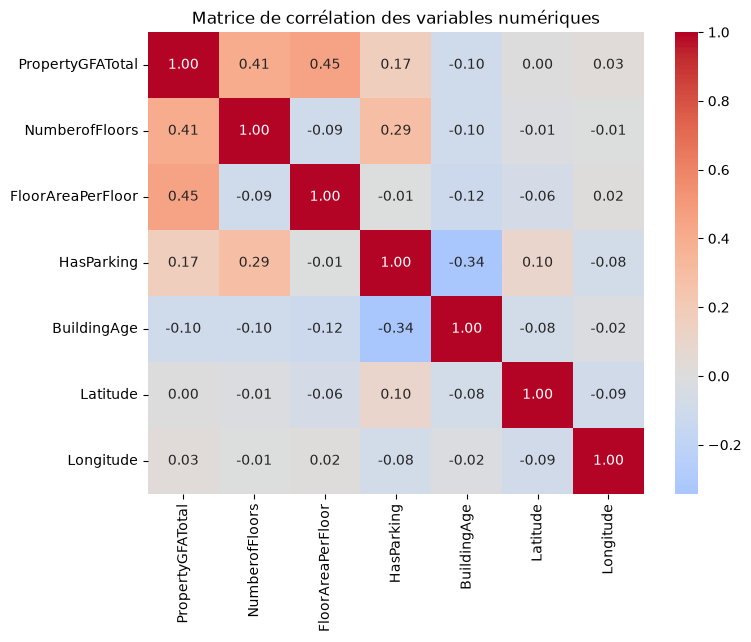

In [78]:
corr = X[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

### Interprétation de la matrice de corrélation

Les variables numériques présentent des corrélations globalement faibles à modérées. La plus forte corrélation observée concerne `PropertyGFATotal` et `FloorAreaPerFloor` (`r = 0,45`), ce qui reste largement inférieur aux seuils généralement associés à une forte colinéarité.

Ces résultats suggèrent que les variables numériques apportent des informations complémentaires. Elles sont donc toutes conservées pour la phase de modélisation.

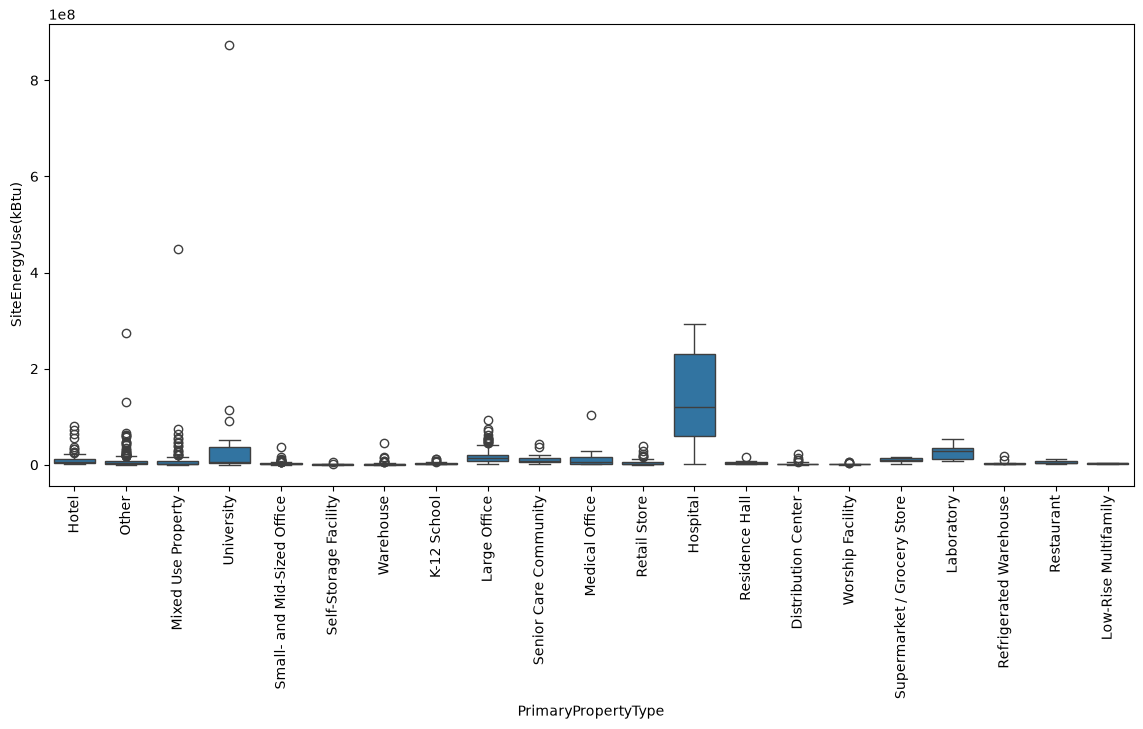

In [79]:
## VARIABLES CATEGORIELLES

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="PrimaryPropertyType",
    y=target
)

plt.xticks(rotation=90)

plt.show()

### Analyse des relations entre les variables explicatives et la cible

Les analyses précédentes ont montré que les caractéristiques physiques des bâtiments, notamment leur surface, sont associées à la consommation énergétique sans toutefois l'expliquer entièrement.

Le boxplot de `PrimaryPropertyType` met en évidence des différences importantes de consommation selon le type de bâtiment. Les hôpitaux, laboratoires ou universités présentent notamment des niveaux de consommation plus élevés que d'autres catégories.

Cette variabilité confirme que le type principal du bâtiment constitue une variable explicative pertinente et justifie son intégration dans la modélisation.

## Train / Test Split

## Séparation des données et construction du pipeline

Le jeu de données est séparé en un ensemble d'entraînement et un ensemble de test.

L'ensemble d'entraînement est utilisé pour ajuster les transformations et entraîner les modèles. L'ensemble de test est conservé à l'écart afin d'obtenir une estimation plus objective des performances sur des données non observées pendant l'apprentissage.

Les opérations de prétraitement sont intégrées dans un pipeline `scikit-learn`. Les valeurs utilisées pour l'imputation, la standardisation et l'encodage sont ainsi apprises uniquement à partir des données d'entraînement, ce qui limite le risque de fuite de données.

In [80]:
# ==========================================================
# Séparation des données en jeux d'entraînement et de test
# ==========================================================

# 80 % des données sont utilisées pour entraîner les modèles
# et 20 % sont conservées pour l'évaluation finale.
#
# Le paramètre random_state garantit que le découpage reste
# identique à chaque exécution du notebook.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Vérification des dimensions obtenues
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

# Vérification de l'absence de valeurs manquantes dans la cible
print("\nNaN dans y_train :", y_train.isna().sum())
print("NaN dans y_test  :", y_test.isna().sum())

print(
    "\nIndex train alignés :",
    X_train.index.equals(y_train.index)
)

print(
    "Index test alignés :",
    X_test.index.equals(y_test.index)
)


X_train : (1238, 9)
X_test  : (310, 9)
y_train : (1238,)
y_test  : (310,)

NaN dans y_train : 0
NaN dans y_test  : 0

Index train alignés : True
Index test alignés : True


### Interprétation

Le découpage conserve 80 % des observations pour l’entraînement et 20 % pour l’évaluation finale. Le paramètre `random_state` garantit la reproductibilité du découpage.

Aucune valeur manquante n’est présente dans les variables cibles des jeux d’entraînement et de test. Les prétraitements et les modèles seront ensuite ajustés uniquement sur le jeu d’entraînement, tandis que le jeu de test restera à l’écart jusqu’à l’évaluation finale.

In [81]:
target_split_summary = pd.DataFrame({
    "Train": y_train.describe(),
    "Test": y_test.describe()
})

target_split_summary

,Train,Test
count,1.238000e+03,3.100000e+02
mean,7.979797e+06,1.237542e+07
std,1.967192e+07,5.780898e+07
min,5.713320e+04,9.055870e+04
25%,1.274345e+06,1.083064e+06
50%,2.732167e+06,2.671165e+06
75%,7.436612e+06,7.169356e+06
max,2.930908e+08,8.739237e+08


### Vérification de la répartition de la cible

Les médianes et les quartiles des jeux d'entraînement et de test sont du même ordre de grandeur. La moyenne est cependant plus élevée dans le jeu de test, ce qui reflète la forte sensibilité de cette statistique aux consommations extrêmes.

Le jeu d'entraînement contient toutefois la valeur maximale du jeu de données, ce qui s'explique par le caractère aléatoire du découpage. Cette différence est acceptable et ne remet pas en cause la représentativité globale des deux ensembles.

### Prétraitement des variables

La plupart des algorithmes de régression utilisés dans cette étude nécessitent des données numériques et ne gèrent pas directement les valeurs manquantes.

Avant l'entraînement des modèles, un pipeline de prétraitement est donc construit afin d'appliquer automatiquement les transformations nécessaires aux variables numériques et catégorielles.

Cette approche garantit que les mêmes traitements seront appliqués de manière identique aux données d'entraînement, aux données de test ainsi qu'à toute nouvelle observation.

Les variables numériques présentent des distributions asymétriques ainsi que plusieurs valeurs extrêmes.

L'imputation par la médiane est retenue pour les variables numériques, car elle est moins sensible aux valeurs atypiques que la moyenne. Les variables catégorielles seront quant à elles imputées par leur modalité la plus fréquente.

Les variables numériques et catégorielles sont donc traitées séparément au moyen d'un ColumnTransformer.

In [82]:
# ==========================================================
# Prétraitement des variables
# ==========================================================

# Variables numériques :
# - remplacement des valeurs manquantes par la médiane ;
# - standardisation pour placer les variables sur des échelles comparables.

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Variables catégorielles :
# - remplacement des valeurs manquantes par la modalité la plus fréquente ;
# - encodage One-Hot ;
# - gestion des catégories inconnues lors de futures prédictions.

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Application du traitement adapté à chaque type de variable
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


L'option `handle_unknown="ignore"` permet de gérer correctement les catégories qui pourraient apparaître dans le jeu de test mais être absentes du jeu d'entraînement.

Le pipeline reste ainsi robuste lors des phases de prédiction.

### Construction d’un modèle naïf de référence

Avant de comparer les modèles de régression, un modèle naïf est construit afin de disposer d’un niveau de performance minimal de référence.

Le `DummyRegressor` ne cherche pas à apprendre une relation entre les variables explicatives et la consommation énergétique. Avec la stratégie `mean`, il prédit pour chaque bâtiment la consommation moyenne observée dans le jeu d’entraînement.

Les futurs modèles devront obtenir de meilleures performances que cette baseline pour être considérés comme informatifs.

Le préprocesseur est intégré au pipeline afin que l’imputation, la standardisation et l’encodage soient appris uniquement à partir des données d’entraînement.

In [83]:
# ==========================================================
# Modèle naïf de référence : DummyRegressor
# ==========================================================

dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)


## Modèles candidats

### Régression linéaire

La régression linéaire constitue le premier modèle supervisé étudié.

Simple et facilement interprétable, elle servira de référence pour évaluer l'intérêt de modèles plus complexes capables de représenter des relations non linéaires.

Comme pour tous les modèles étudiés, le prétraitement est intégré au pipeline afin que les transformations soient apprises uniquement sur le jeu d'entraînement.

In [87]:

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

### Support Vector Regression (SVR)

Un modèle SVR est également évalué afin d'introduire une famille de modèles différente des approches linéaires et des modèles fondés sur les arbres. Avec son noyau par défaut (RBF), il peut modéliser des relations non linéaires.

Comme pour les autres modèles, le prétraitement est intégré au pipeline.

In [84]:
svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR())
    ]
)

### Arbre de décision

Un arbre de décision est testé afin de modéliser d’éventuelles relations non linéaires entre les caractéristiques des bâtiments et leur consommation énergétique.

Contrairement à la régression linéaire, il peut représenter des interactions entre les variables et des effets de seuil. Utilisé avec ses paramètres par défaut, il peut toutefois présenter un risque de surapprentissage.

In [88]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

### Random Forest

Le modèle Random Forest est une méthode d'ensemble fondée sur plusieurs arbres de décision.

Contrairement à un arbre unique, qui peut fortement s'adapter aux données d'entraînement, la Random Forest entraîne plusieurs arbres sur des sous-échantillons différents des données et combine ensuite leurs prédictions.

Cette approche permet généralement de réduire le surapprentissage et d'obtenir des prédictions plus robustes.

Le modèle est ici entraîné avec ses paramètres par défaut afin de comparer équitablement plusieurs familles de modèles avant toute phase d'optimisation.

In [89]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

### Comparaison des modèles par validation croisée

Les 4 modèles supervisés sont comparés par validation croisée à cinq plis. Le `DummyRegressor` est également évalué selon le même protocole afin de fournir une baseline naïve.

À chaque itération, une partie des données d'entraînement sert à ajuster le modèle et une autre partie sert à mesurer ses performances. Cette procédure fournit une estimation plus robuste de la capacité de généralisation qu'une seule séparation des données.

Le jeu de test reste totalement indépendant pendant cette étape. Il ne sera utilisé qu'une seule fois, après la sélection et l'optimisation du modèle final.

Trois métriques sont étudiées :

- la MAE, qui mesure l'erreur absolue moyenne ;
- la RMSE, qui pénalise davantage les erreurs importantes ;
- le coefficient de détermination R², qui mesure la part de variabilité expliquée par le modèle.

In [90]:
# ==========================================================
# Fonction commune d'évaluation par validation croisée
# ==========================================================

# Stratégie commune à tous les modèles :
# - 5 plis ;
# - mélange des observations ;
# - découpage reproductible.
cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def evaluate_model(model, model_name, X_train, y_train):
    """
    Évalue un pipeline de régression par validation croisée.

    La validation croisée est réalisée uniquement sur le jeu
    d'entraînement. Le jeu de test reste indépendant de la comparaison
    et de la sélection des modèles.

    Paramètres
    ----------
    model : estimateur scikit-learn
        Pipeline contenant le prétraitement et le modèle de régression.

    model_name : str
        Nom du modèle affiché dans le tableau de résultats.

    X_train : pandas.DataFrame
        Variables explicatives du jeu d'entraînement.

    y_train : pandas.Series
        Variable cible du jeu d'entraînement.

    Retour
    ------
    dict
        Moyennes et écarts-types des métriques obtenues sur les plis
        de validation croisée.
    """

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv_strategy,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=True,
        n_jobs=-1
    )

    # Scores moyens de validation
    mae_validation = -scores["test_MAE"].mean()
    rmse_validation = -scores["test_RMSE"].mean()
    r2_validation = scores["test_R2"].mean()

    # Variabilité des scores entre les plis
    mae_validation_std = scores["test_MAE"].std()
    rmse_validation_std = scores["test_RMSE"].std()
    r2_validation_std = scores["test_R2"].std()

    # Scores moyens d'entraînement
    rmse_train = -scores["train_RMSE"].mean()
    r2_train = scores["train_R2"].mean()

    print(f"\n{model_name}")
    print(f"RMSE entraînement : {rmse_train:,.0f} kBtu")
    print(
        f"RMSE validation   : {rmse_validation:,.0f} "
        f"± {rmse_validation_std:,.0f} kBtu"
    )
    print(
        f"MAE validation    : {mae_validation:,.0f} "
        f"± {mae_validation_std:,.0f} kBtu"
    )
    print(f"R² entraînement   : {r2_train:.3f}")
    print(
        f"R² validation     : {r2_validation:.3f} "
        f"± {r2_validation_std:.3f}"
    )

    return {
        "Modèle": model_name,
        "MAE validation": mae_validation,
        "Écart-type MAE": mae_validation_std,
        "RMSE validation": rmse_validation,
        "Écart-type RMSE": rmse_validation_std,
        "R² validation": r2_validation,
        "Écart-type R²": r2_validation_std,
        "RMSE entraînement": rmse_train,
        "R² entraînement": r2_train
    }

In [91]:
# ==========================================================
# Comparaison des modèles sur le jeu d'entraînement
# ==========================================================

dummy_results = evaluate_model(
    model=dummy_model,
    model_name="Dummy Regressor",
    X_train=X_train,
    y_train=y_train
)

linear_results = evaluate_model(
    model=linear_model,
    model_name="Régression linéaire",
    X_train=X_train,
    y_train=y_train
)

svr_results = evaluate_model(
    model=svr_model,
    model_name="SVR",
    X_train=X_train,
    y_train=y_train
)

tree_results = evaluate_model(
    model=decision_tree,
    model_name="Arbre de décision",
    X_train=X_train,
    y_train=y_train
)

forest_results = evaluate_model(
    model=random_forest,
    model_name="Random Forest",
    X_train=X_train,
    y_train=y_train
)


Dummy Regressor
RMSE entraînement : 19,641,449 kBtu
RMSE validation   : 19,141,474 ± 4,590,191 kBtu
MAE validation    : 8,383,813 ± 589,806 kBtu
R² entraînement   : 0.000
R² validation     : -0.012 ± 0.020

Régression linéaire
RMSE entraînement : 10,187,581 kBtu
RMSE validation   : 14,425,232 ± 4,430,976 kBtu
MAE validation    : 4,709,494 ± 662,480 kBtu
R² entraînement   : 0.729
R² validation     : 0.285 ± 0.444

SVR
RMSE entraînement : 20,333,316 kBtu
RMSE validation   : 19,795,777 ± 4,763,632 kBtu
MAE validation    : 6,640,165 ± 969,038 kBtu
R² entraînement   : -0.072
R² validation     : -0.082 ± 0.024

Arbre de décision
RMSE entraînement : -0 kBtu
RMSE validation   : 15,341,485 ± 7,546,401 kBtu
MAE validation    : 5,157,413 ± 1,027,445 kBtu
R² entraînement   : 1.000
R² validation     : 0.166 ± 0.644

Random Forest
RMSE entraînement : 4,553,629 kBtu
RMSE validation   : 11,305,257 ± 3,002,921 kBtu
MAE validation    : 3,744,047 ± 391,068 kBtu
R² entraînement   : 0.946
R² validation   

In [92]:
# Regroupement et classement des résultats
cv_results = pd.DataFrame([
    dummy_results,
    linear_results,
    svr_results,
    tree_results,
    forest_results
])

cv_results = (
    cv_results
    .sort_values(
        by="RMSE validation",
        ascending=True
    )
    .reset_index(drop=True)
)

cv_results

,Modèle,MAE validation,Écart-type MAE,RMSE validation,Écart-type RMSE,R² validation,Écart-type R²,RMSE entraînement,R² entraînement
0,Random Forest,3.744047e+06,3.910683e+05,1.130526e+07,3.002921e+06,0.593901,0.194216,4.553629e+06,0.945729
1,Régression linéaire,4.709494e+06,6.624803e+05,1.442523e+07,4.430976e+06,0.284516,0.444261,1.018758e+07,0.729089
2,Arbre de décision,5.157413e+06,1.027445e+06,1.534149e+07,7.546401e+06,0.165883,0.644363,-0.000000e+00,1.000000
3,Dummy Regressor,8.383813e+06,5.898061e+05,1.914147e+07,4.590191e+06,-0.012006,0.020103,1.964145e+07,0.000000
4,SVR,6.640165e+06,9.690377e+05,1.979578e+07,4.763632e+06,-0.081875,0.023505,2.033332e+07,-0.071732


### Interprétation de la comparaison des modèles

Le DummyRegressor obtient des performances faibles, avec un coefficient R² proche de zéro. Les modèles supervisés les plus performants apportent donc une amélioration réelle par rapport à une prédiction naïve fondée uniquement sur la consommation moyenne du jeu d’entraînement.

La Random Forest obtient les meilleures performances en validation croisée, avec la RMSE la plus faible (11,31 millions de kBtu), la MAE la plus faible (3,74 millions de kBtu) et le meilleur coefficient R² moyen (0,594).

La régression linéaire arrive en deuxième position, avec une RMSE de 14,43 millions de kBtu et un R² moyen de 0,285.

L’arbre de décision présente un surapprentissage marqué : ses performances sont parfaites sur les données d’entraînement, mais nettement moins bonnes en validation croisée.

Le SVR, testé afin de représenter une troisième famille de modèles, obtient ici des performances inférieures à la baseline, avec un R² moyen négatif (-0,082).

Les écarts-types élevés observés pour plusieurs modèles montrent que les performances varient selon les plis. Cette instabilité est vraisemblablement liée à la forte asymétrie de la cible et au poids de quelques bâtiments présentant des consommations extrêmement élevées.

La Random Forest obtenant les meilleures performances en validation croisée, une optimisation de ses hyperparamètres est réalisée afin d'évaluer son potentiel d'amélioration.

Cette étape permet de vérifier si un réglage des hyperparamètres réduit son surapprentissage et améliore sa capacité de généralisation. La comparaison finale reste fondée sur les performances obtenues en validation croisée, principalement selon la RMSE.

## Optimisation complémentaire de la Random Forest

La Random Forest obtient les meilleures performances lors de la comparaison initiale des modèles supervisés, avec la RMSE et la MAE de validation croisée les plus faibles ainsi que le meilleur coefficient R² moyen. Elle présente toutefois un écart important entre ses performances d’entraînement et de validation, suggérant un surapprentissage.

Une optimisation de ses hyperparamètres est donc menée afin de vérifier si la réduction de ce surapprentissage permet d'améliorer sa capacité de généralisation. Le modèle final sera sélectionné après comparaison des performances obtenues avec le même protocole de validation croisée.

La comparaison initiale montre que la Random Forest obtient les meilleures performances moyennes en validation croisée. Elle présente toutefois un écart important entre ses performances d'entraînement et de validation, suggérant un surapprentissage.

La Random Forest est donc optimisée afin de vérifier si le réglage de ses hyperparamètres permet de réduire ce surapprentissage et d'améliorer sa capacité de généralisation. Le modèle final sera retenu uniquement sur la base des performances obtenues après cette étape.

In [93]:
### Vérification du fonctionnement avec une grille réduite
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :")
print(grid_search.best_params_)

print(
    "\nMeilleure RMSE moyenne en validation croisée :",
    f"{-grid_search.best_score_:,.0f} kBtu"
)

Meilleurs hyperparamètres :
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Meilleure RMSE moyenne en validation croisée : 11,138,119 kBtu


In [94]:
### Recherche finale sur une grille élargie

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
}

# 3 × 3 × 4 × 3 = 108 combinaisons
grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print("Nombre de combinaisons testées :", len(grid_search.cv_results_["params"]))
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print(
    "Meilleure RMSE moyenne en validation croisée : "
    f"{-grid_search.best_score_:,.0f} kBtu"
)

Nombre de combinaisons testées : 108
Meilleurs hyperparamètres : {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Meilleure RMSE moyenne en validation croisée : 11,103,252 kBtu


La recherche sur grille a évalué 108 combinaisons d'hyperparamètres et identifie comme meilleure configuration :

n_estimators = 300
max_depth = 20
min_samples_split = 2
min_samples_leaf = 1

Cette configuration obtient une RMSE moyenne de 11 103 252 kBtu en validation croisée.

L'optimisation améliore légèrement les performances de la Random Forest par rapport au modèle utilisant les paramètres par défaut, dont la RMSE moyenne était de 11 305 257 kBtu.

La Random Forest optimisée conserve ainsi la meilleure RMSE moyenne parmi les modèles étudiés et constitue à ce stade le meilleur candidat pour le modèle final.

## Sélection du modèle final

La comparaison des modèles montre que la Random Forest obtient les meilleures performances selon la métrique principale retenue, la RMSE moyenne obtenue en validation croisée.

Après optimisation de ses hyperparamètres, sa RMSE moyenne atteint 11 103 252 kBtu, contre 11 305 257 kBtu avec les paramètres par défaut. La Random Forest optimisée est donc retenue comme modèle final.

Son évaluation sur le jeu de test permettra d'estimer ses performances sur des données totalement inédites.

### Évaluation finale sur le jeu de test

Le modèle retenu est maintenant entraîné sur l'ensemble du jeu d'entraînement puis évalué sur le jeu de test, qui n'a jamais été utilisé lors de la comparaison des modèles ni pendant la recherche des hyperparamètres.

Cette évaluation fournit une estimation de la capacité de généralisation du modèle sur de nouvelles observations.

In [95]:
# ==========================================================
# Évaluation finale de la Random Forest optimisée
# ==========================================================

# Récupération du meilleur modèle issu de la recherche sur grille
final_model = grid_search.best_estimator_

# Prédictions sur le jeu de test
y_pred = final_model.predict(X_test)

# Calcul des métriques
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Performances du modèle final")
print(f"MAE  : {mae:,.0f} kBtu")
print(f"RMSE : {rmse:,.0f} kBtu")
print(f"R²   : {r2:.3f}")

Performances du modèle final
MAE  : 7,833,787 kBtu
RMSE : 52,193,798 kBtu
R²   : 0.182


### Interprétation des performances sur le jeu de test

L'évaluation sur le jeu de test montre que la Random Forest optimisée conserve un pouvoir prédictif limité sur des observations inédites, avec un R² de 0,182. Cela signifie qu'environ 18 % de la variabilité de la consommation énergétique du jeu de test est expliquée par les variables utilisées par le modèle.

Les erreurs restent importantes, avec une MAE d'environ 7,83 millions de kBtu et une RMSE d'environ 52,19 millions de kBtu. L'écart très marqué entre ces deux métriques indique que certaines observations génèrent des erreurs particulièrement élevées.

Ces résultats sont cohérents avec la forte asymétrie de la cible et avec la présence, dans le jeu de test, de bâtiments présentant des consommations très élevées par rapport à celles observées dans le jeu d'entraînement.

La Random Forest optimisée reste néanmoins le modèle retenu, car sa sélection a été effectuée uniquement à partir des performances obtenues en validation croisée, sans utiliser le jeu de test pour choisir entre les modèles.

### Illustration de quelques prédictions

Cet extrait illustre le comportement du modèle sur quelques observations du jeu de test. Il met en évidence des prédictions parfois proches des valeurs réelles, mais également des sous-estimations et des surestimations importantes.

In [96]:
# Comparaison de quelques valeurs réelles et prédites
comparison = pd.DataFrame({
    "Valeur réelle": y_test.to_numpy(),
    "Prédiction": y_pred
})

comparison.head(10)

,Valeur réelle,Prédiction
0,4.483853e+08,3.267809e+07
1,1.596586e+07,8.120345e+06
2,2.070006e+06,1.232120e+06
3,1.302193e+06,1.145702e+06
4,3.534691e+06,3.032541e+06
5,4.897760e+06,5.160657e+06
6,1.124543e+06,2.071410e+06
7,1.441665e+06,8.400416e+06
8,1.146485e+08,6.995248e+07
9,1.629600e+05,1.126851e+06


### Comparaison de quelques prédictions

Les premières prédictions montrent que la Random Forest reproduit correctement l'ordre de grandeur de certaines consommations, mais que des écarts importants subsistent pour certains bâtiments.

Le modèle tend notamment à sous-estimer fortement certaines consommations très élevées. Par exemple, une consommation réelle d'environ 448 millions de kBtu est prédite à environ 33 millions de kBtu.

Ces observations sont cohérentes avec les métriques obtenues sur le jeu de test. Elles illustrent notamment l'écart important entre la MAE et la RMSE : quelques erreurs de très grande amplitude pénalisent fortement la RMSE et montrent que le modèle reste moins précis pour les bâtiments présentant des consommations particulièrement élevées.

## Interprétation du modèle final

Au-delà des performances prédictives, il est intéressant d'identifier les variables qui contribuent le plus aux prédictions du modèle.

Une importance par permutation est calculée sur le jeu de test. Cette méthode mesure la diminution des performances lorsque les valeurs d'une variable sont mélangées aléatoirement. Plus la performance se dégrade, plus la variable est considérée comme importante pour les prédictions.

Cette approche présente l'avantage d'être applicable à l'ensemble du pipeline de modélisation, indépendamment du type de modèle ou du prétraitement réalisé.

In [97]:
# ==========================================================
# Importance globale par permutation du modèle final
# ==========================================================

permutation_results = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance moyenne": permutation_results.importances_mean,
    "Écart-type": permutation_results.importances_std
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance moyenne",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Variable,Importance moyenne,Écart-type
0,PropertyGFATotal,6.368781e+06,651979.303633
1,PrimaryPropertyType,1.958167e+05,525460.047740
2,Longitude,8.667914e+04,136487.586874
3,NumberofFloors,6.959340e+04,44135.847835
4,Latitude,5.024485e+04,62369.921439
5,LargestPropertyUseType,4.389960e+04,703920.763822
6,HasParking,-1.648664e+03,16646.164358
7,BuildingAge,-9.503047e+03,42125.791007
8,FloorAreaPerFloor,-5.412835e+05,659581.971055


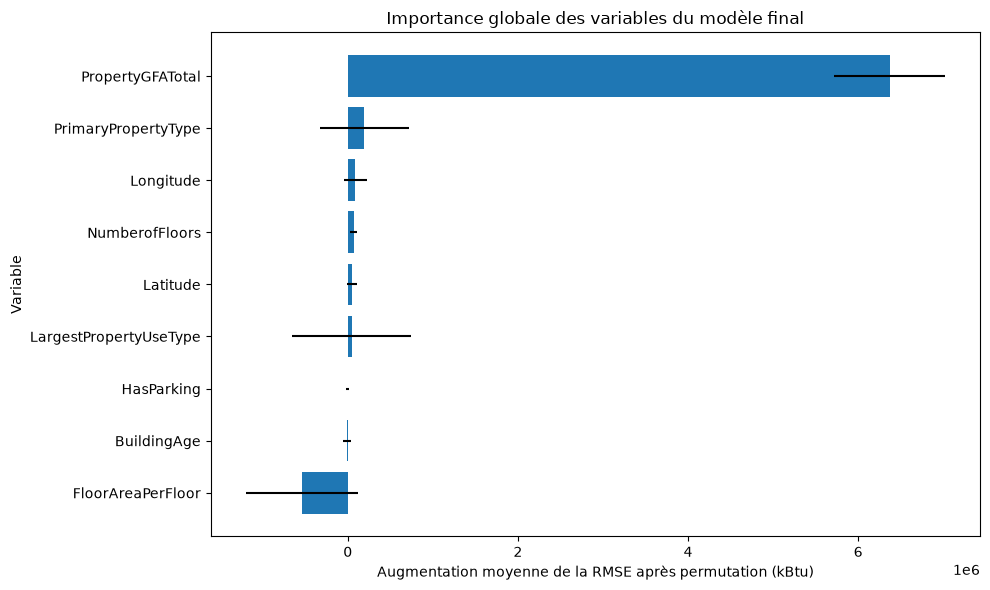

In [99]:
# Préparation des variables pour la visualisation des importances
top_features = feature_importance.head(10).sort_values(
    by="Importance moyenne",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Variable"],
    top_features["Importance moyenne"],
    xerr=top_features["Écart-type"]
)

plt.title(
    "Importance globale des variables du modèle final"
)
plt.xlabel(
    "Augmentation moyenne de la RMSE après permutation (kBtu)"
)
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

### Interprétation des variables importantes

PropertyGFATotal est de très loin la variable dont la permutation dégrade le plus fortement la performance du modèle. La surface totale constitue donc la variable la plus influente dans les prédictions de la Random Forest retenue.

PrimaryPropertyType arrive en deuxième position, mais avec une importance nettement plus faible. Longitude, NumberofFloors, Latitude et LargestPropertyUseType présentent également des importances positives mais limitées au regard de celle de la surface totale.

HasParking et BuildingAge présentent des importances proches de zéro. FloorAreaPerFloor présente une importance moyenne négative sur cet échantillon : sa permutation n'altère pas la performance du modèle et peut même l'améliorer légèrement.

Les écarts-types observés invitent toutefois à interpréter avec prudence les faibles importances, certaines étant proches de zéro au regard de leur variabilité.

Ces résultats décrivent le fonctionnement du modèle et ne permettent pas, à eux seuls, d'établir des relations causales entre les caractéristiques des bâtiments et leur consommation énergétique.

## Enregistrement du pipeline final pour la Mission 2

In [100]:
import bentoml

final_pipeline = final_model

saved_model = bentoml.sklearn.save_model(
    "seattle_energy_model",
    final_pipeline,
    metadata={
        "target": "SiteEnergyUse(kBtu)",
        "model_type": "RandomForestRegressor",
        "reference_year": 2016,
    },
)

print(f"Modèle enregistré : {saved_model.tag}")

Modèle enregistré : seattle_energy_model:vekvkwfo2cew7an6


## Conclusion

Cette étude avait pour objectif d'estimer la consommation énergétique des bâtiments non résidentiels de Seattle à partir de caractéristiques disponibles indépendamment de leur consommation mesurée.

L'analyse exploratoire a permis de définir le périmètre de l'étude, d'identifier une cible fortement asymétrique et de contrôler la qualité des données. Après exclusion des bâtiments résidentiels, seuls les bâtiments dont le ComplianceStatus est Compliant et qui ne sont pas signalés comme valeurs aberrantes dans Outlier ont été conservés. Le jeu de données utilisé pour la modélisation contient ainsi 1 548 bâtiments. Trois nouvelles variables ont également été créées afin de représenter l'ancienneté, la structure et la présence d'un parking.

Quatre modèles supervisés appartenant à trois familles distinctes ont été comparés selon un protocole commun de validation croisée appliqué exclusivement au jeu d'entraînement : régression linéaire, SVR, arbre de décision et Random Forest. Un DummyRegressor a également été utilisé comme baseline. La Random Forest obtient les meilleures performances en validation croisée. Après optimisation de ses hyperparamètres, sa RMSE moyenne atteint environ 11,10 millions de kBtu.

Sur le jeu de test indépendant, la Random Forest optimisée obtient un R² de 0,182, une MAE d'environ 7,83 millions de kBtu et une RMSE d'environ 52,19 millions de kBtu. L'écart important entre la MAE et la RMSE montre que certaines observations génèrent des erreurs particulièrement élevées. Ces résultats soulignent les limites de généralisation du modèle pour les bâtiments présentant des consommations très élevées.

L'importance par permutation montre que les prédictions reposent principalement sur la surface totale du bâtiment (PropertyGFATotal), dont l'influence est très supérieure à celle des autres variables. Ces résultats caractérisent le fonctionnement du modèle retenu, sans permettre de conclure à des relations causales.

Des améliorations pourraient notamment consister à tester une transformation logarithmique de la cible, des modèles régularisés ou des variables structurelles complémentaires disponibles avant la mesure de la consommation.



In [101]:
print(sorted(df["PrimaryPropertyType"].dropna().unique()))
print(sorted(df["LargestPropertyUseType"].dropna().unique()))

['Distribution Center', 'Hospital', 'Hotel', 'K-12 School', 'Laboratory', 'Large Office', 'Low-Rise Multifamily', 'Medical Office', 'Mixed Use Property', 'Other', 'Refrigerated Warehouse', 'Residence Hall', 'Restaurant', 'Retail Store', 'Self-Storage Facility', 'Senior Care Community', 'Small- and Mid-Sized Office', 'Supermarket / Grocery Store', 'University', 'Warehouse', 'Worship Facility']
['Adult Education', 'Automobile Dealership', 'Bank Branch', 'College/University', 'Courthouse', 'Data Center', 'Distribution Center', 'Financial Office', 'Fire Station', 'Fitness Center/Health Club/Gym', 'Food Service', 'Hospital (General Medical & Surgical)', 'Hotel', 'K-12 School', 'Laboratory', 'Library', 'Lifestyle Center', 'Manufacturing/Industrial Plant', 'Medical Office', 'Movie Theater', 'Multifamily Housing', 'Museum', 'Non-Refrigerated Warehouse', 'Office', 'Other', 'Other - Education', 'Other - Entertainment/Public Assembly', 'Other - Lodging/Residential', 'Other - Mall', 'Other - Publi